In [11]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../datasets/ml_training_dataset_v5.csv")

X = df[
    [
        'application_type',
        'expected_users_per_day',
        'concurrent_users',
        'storage_required_gb',
        'deployment_region',
        'traffic_pattern'
    ]
]

# One-hot encode
X = pd.get_dummies(X)

# Load trained model
rf_model = joblib.load("../models/cloud_model.pkl")
from sklearn.model_selection import train_test_split

y = df[
    [
        'required_vcpu',
        'required_ram_gb'
    ]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_predictions = rf_model.predict(X_test)

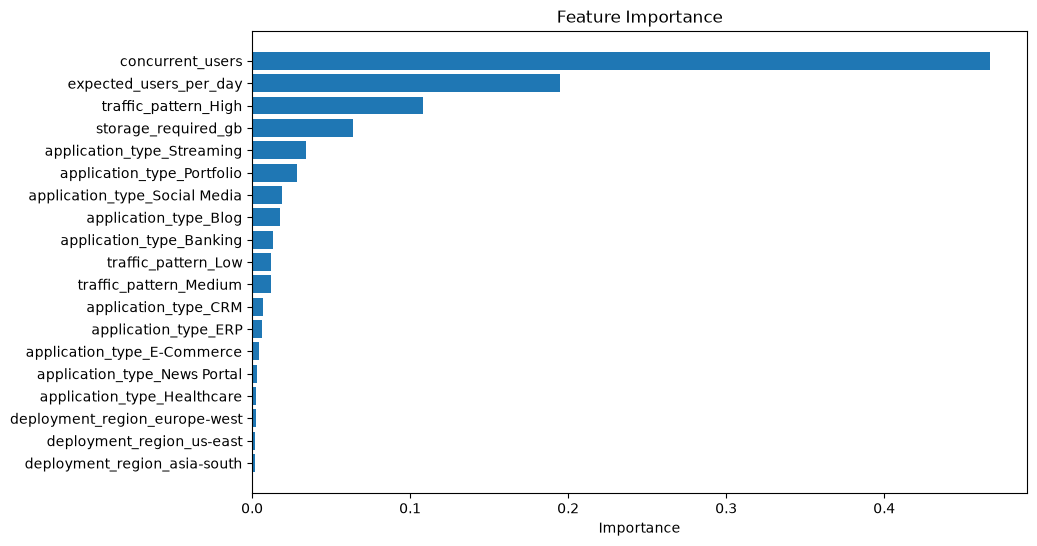

In [12]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [13]:
feature_importance.head(10)

,Feature,Importance
1,concurrent_users,0.467060
0,expected_users_per_day,0.195145
16,traffic_pattern_High,0.108173
2,storage_required_gb,0.064041
12,application_type_Streaming,0.033965
10,application_type_Portfolio,0.028456
11,application_type_Social Media,0.018969
4,application_type_Blog,0.017677
3,application_type_Banking,0.013150
17,traffic_pattern_Low,0.012264


In [14]:
df.groupby("required_vcpu")["expected_users_per_day"].describe()

,count,mean,std,min,25%,50%,75%,max
required_vcpu,,,,,,,,
1,1200.0,1740.805833,6859.561946,200.0,298.00,478.0,1025.75,121727.0
2,3000.0,8306.864333,31561.107598,200.0,496.00,1168.5,3930.00,425392.0
4,6000.0,43069.427667,83587.700256,201.0,2272.00,9404.5,37965.25,498736.0
8,3600.0,116605.733611,123858.905869,535.0,23203.25,66574.5,171779.00,499794.0
16,1200.0,226632.992500,138334.010059,5101.0,104676.75,212242.5,334177.50,499931.0


In [15]:
df.groupby("required_vcpu")["concurrent_users"].describe()

,count,mean,std,min,25%,50%,75%,max
required_vcpu,,,,,,,,
1,1200.0,58.110000,122.331818,1.0,11.00,22.0,52.00,1853.0
2,3000.0,206.773000,484.366184,1.0,22.00,61.0,208.25,7482.0
4,6000.0,1152.665667,2572.116264,2.0,76.00,318.0,1082.25,64538.0
8,3600.0,6073.103333,8697.516661,5.0,885.75,2863.0,7679.25,90463.0
16,1200.0,15991.014167,15768.380808,55.0,5069.00,11447.5,20901.00,113073.0


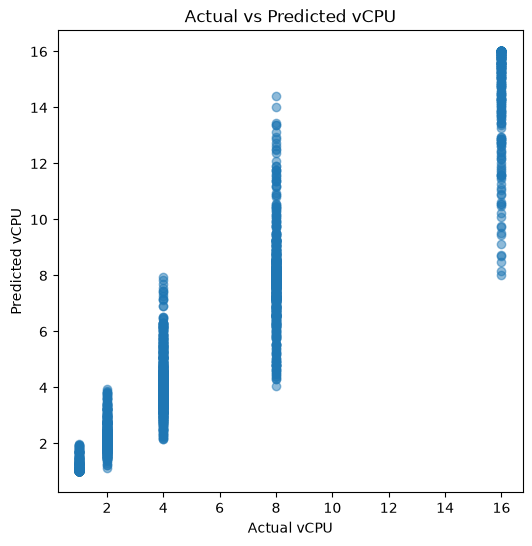

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test["required_vcpu"],
    rf_predictions[:,0],
    alpha=0.5
)

plt.xlabel("Actual vCPU")
plt.ylabel("Predicted vCPU")
plt.title("Actual vs Predicted vCPU")

plt.show()

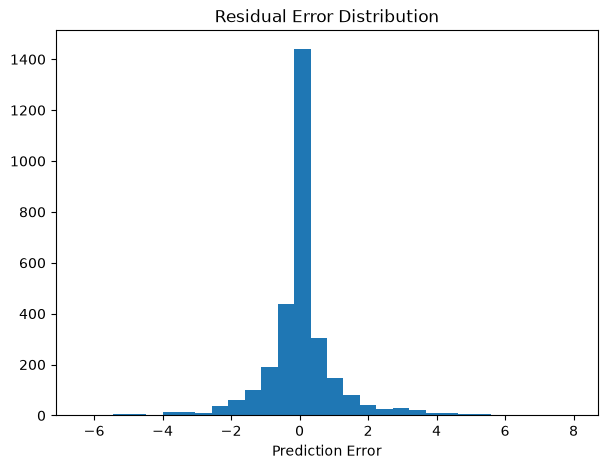

In [17]:
residuals = y_test["required_vcpu"] - rf_predictions[:,0]

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")

plt.show()

In [18]:
# comparison = pd.DataFrame({
#     "Model":["Linear Regression","Random Forest"],
#     "MAE":[0.84648,0.00067],
#     "RMSE":[1.19268,0.02838],
#     "R2":[0.9215,0.99995]
# })

# comparison
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

comparison = pd.DataFrame({
    "Model": ["Random Forest"],
    "vCPU MAE": [mean_absolute_error(y_test["required_vcpu"], rf_predictions[:, 0])],
    "vCPU RMSE": [mean_squared_error(y_test["required_vcpu"], rf_predictions[:, 0]) ** 0.5],
    "vCPU R2": [r2_score(y_test["required_vcpu"], rf_predictions[:, 0])],
    "RAM MAE": [mean_absolute_error(y_test["required_ram_gb"], rf_predictions[:, 1])],
    "RAM RMSE": [mean_squared_error(y_test["required_ram_gb"], rf_predictions[:, 1]) ** 0.5],
    "RAM R2": [r2_score(y_test["required_ram_gb"], rf_predictions[:, 1])]
})

comparison

,Model,vCPU MAE,vCPU RMSE,vCPU R2,RAM MAE,RAM RMSE,RAM R2
0,Random Forest,0.622713,1.137884,0.914438,1.245427,2.275767,0.914438
